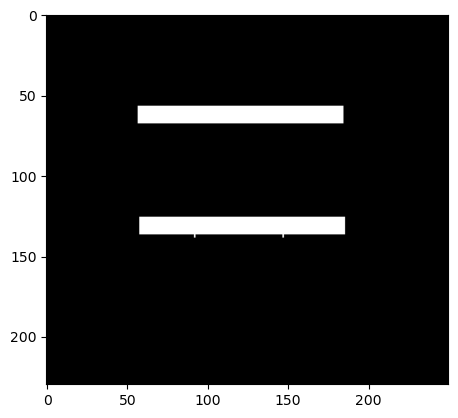

In [3]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/RECT.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.show()

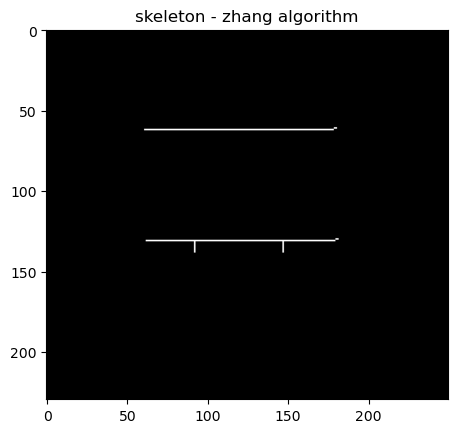

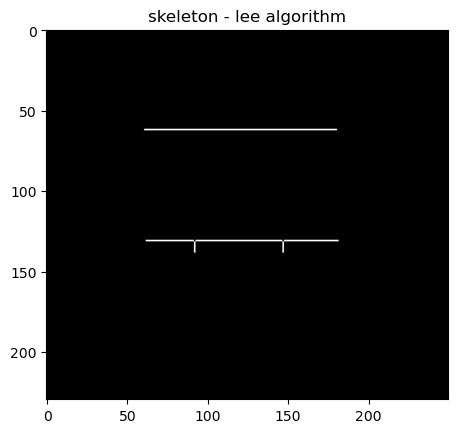

In [4]:
#Efectúe la esqueletización de esta imagen

from skimage.morphology import skeletonize, thin

sk_image = skeletonize(image, method="zhang")

plt.imshow(sk_image, cmap="gray")
plt.title("skeleton - zhang algorithm")
plt.show()

sk_image = skeletonize(image, method="lee")

plt.imshow(sk_image, cmap="gray")
plt.title("skeleton - lee algorithm")
plt.show()


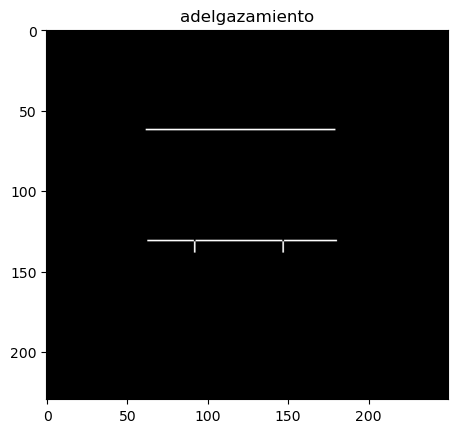

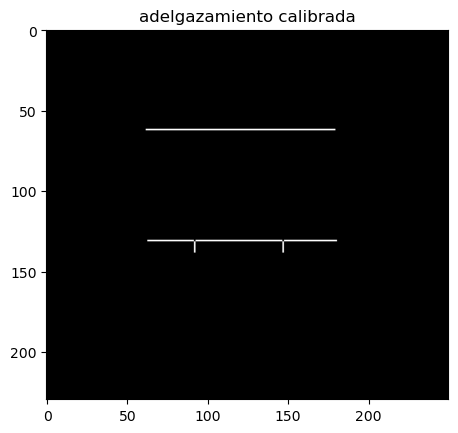

In [5]:
from skimage import exposure

#Efectúe un adelgazamiento de la imagen original
th_image = thin(image)

plt.imshow(th_image, cmap="gray")
plt.title("adelgazamiento")
plt.show()

# Calibracion
rescaled_img = exposure.rescale_intensity(th_image, in_range=(th_image.min(),th_image.max()), out_range=(0,255))
plt.imshow(rescaled_img, cmap="gray")
plt.title("adelgazamiento calibrada")
plt.show()

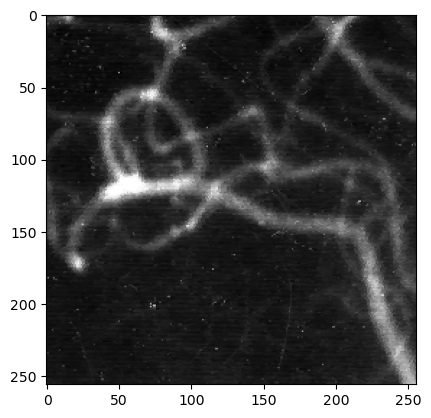

In [6]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/ANGIO.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.show()

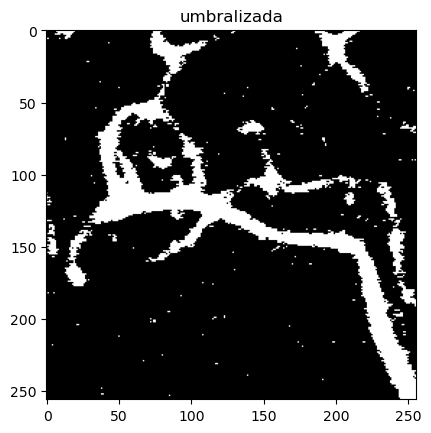

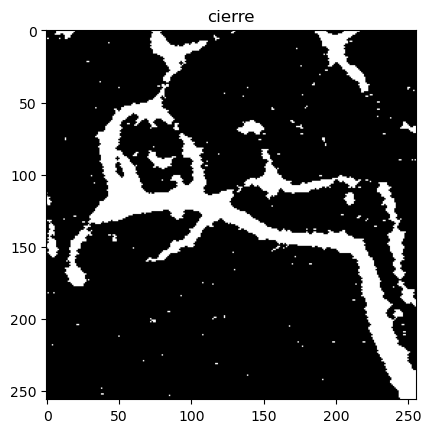

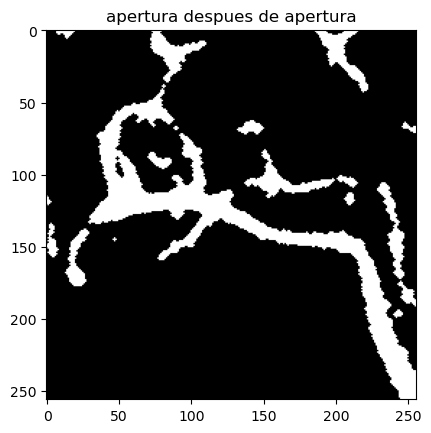

In [7]:
#Umbralice la imagen utilizando el algoritmo de OTSU,
# después fíltrela efectuando un cierre y una apertura de la imagen, con una máscara en cruz de 3x3.

import numpy as np
from skimage.morphology import dilation, erosion, opening, closing

# Umbralizar con OTSU
retval, umbralizada = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU)

plt.imshow(umbralizada, cmap="gray")
plt.title("umbralizada")
plt.show()

# Efectura cierre con mascara de cruz 3x3
fp = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
])

closing_image = closing(umbralizada, footprint=fp)

plt.imshow(closing_image, cmap="gray")
plt.title("cierre")
plt.show()

opening_image = opening(closing_image, footprint=fp)

plt.imshow(opening_image, cmap="gray")
plt.title("apertura despues de apertura")
plt.show()

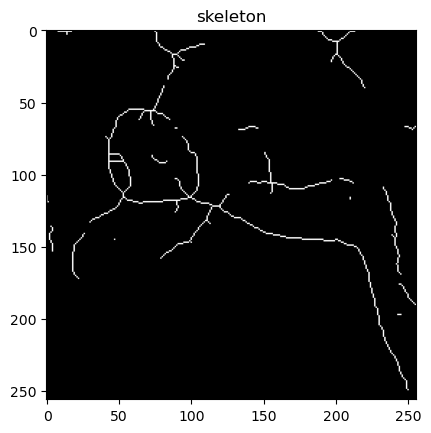

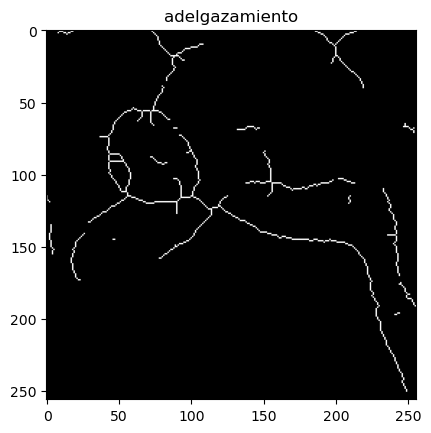

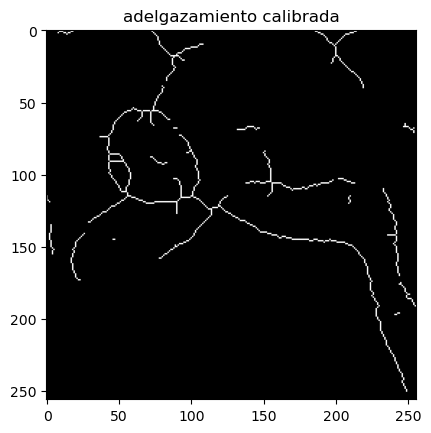

In [8]:
#Efectúe su esqueletización y su adelgazamiento. Compare los resultados de estos dos tratamientos.

# Eskeleto
sk_image = skeletonize(opening_image, method="zhang")

plt.imshow(sk_image, cmap="gray")
plt.title("skeleton")
plt.show()

# Adelgazamiento
th_image = thin(opening_image)

plt.imshow(th_image, cmap="gray")
plt.title("adelgazamiento")
plt.show()

# Calibracion
rescaled_img = exposure.rescale_intensity(th_image, in_range=(th_image.min(),th_image.max()), out_range=(0,255))
plt.imshow(rescaled_img, cmap="gray")
plt.title("adelgazamiento calibrada")
plt.show()

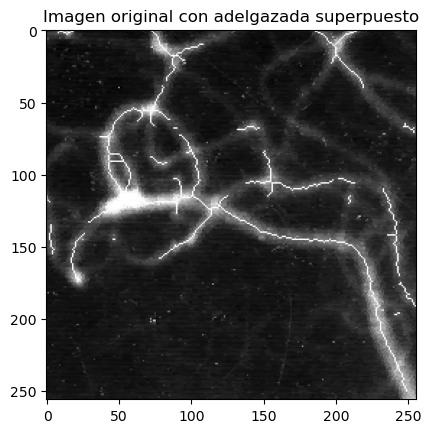

In [9]:
#Sobreponga la imagen adelgazada a la imagen angio.png (calculando el máximo entre las dos imágenes) para observar la localización de las líneas con respecto a la imagen inicial

superpuesta = np.maximum(image, th_image*255)

plt.imshow(superpuesta, cmap="gray")
plt.title("Imagen original con adelgazada superpuesto")
plt.show()